## Variável Qualitativa Ordinal — Nível de Automação

Este notebook atende ao critério **"Tabela com a distribuição de frequências da variável qualitativa e representação gráfica"** e ao critério **"Medidas resumo para a variável qualitativa"** da rubrica da sprint 1.

**Base de dados:** `Eficiencia Operacional em Linhas de Producao.xlsx` (n = 1000 linhas de produção)

**Variável analisada:** `Nivel_Automacao` — qualitativa **ordinal**, com as
categorias Baixa, Média e Alta, que possuem ordem natural de grandeza

#### 1. Definindo e importando as bibliotecas necessárias para a execução do código

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Importando e lendo a base de dados para o script

In [68]:
database = 'refs/Eficiencia Operacional em Linhas de Producao.xlsx'
df = pd.read_excel(database)
df

,Nivel_Automacao,Tempo_Ciclo_s,Unidades_Produzidas
0,Alta,52.42,523
1,Baixa,43.03,643
2,Média,58.33,421
3,Baixa,55.95,495
4,Alta,36.54,832
...,...,...,...
995,Baixa,54.31,446
996,Média,49.62,601
997,Alta,51.04,597
998,Média,57.56,400


#### 3. Montando Tabela de Frequências para Nivel_Automacao

In [69]:
# 3.1 Contagem de frequências por categoria

df2 = df.Nivel_Automacao.value_counts()
df2

Nivel_Automacao
Média    465
Alta     331
Baixa    204
Name: count, dtype: int64

In [70]:
# 3.2 Total de elementos da amostra
totaldf2 = df2.sum()
totaldf2

1000

In [71]:
# 3.3 Criando o DataFrame da tabela de frequência na variável Nivel_automacao
dadosvquali = pd.DataFrame(df2).reset_index()
dadosvquali.columns = ['Nível Automação', 'Frequência']
dadosvquali

,Nível Automação,Frequência
0,Média,465
1,Alta,331
2,Baixa,204


In [72]:
# 3.4 Calculando a frequência relativa (%) em Nivel_Automacao com 2 casas decimais
dadosvquali['Frequência Relativa (%)'] = round(dadosvquali['Frequência'] * 100 / totaldf2, 2)
dadosvquali

,Nível Automação,Frequência,Frequência Relativa (%)
0,Média,465,46.5
1,Alta,331,33.1
2,Baixa,204,20.4


In [73]:
# 3.5 Reordenando a tabela de nível automação respeitando a escala ordinal (Baixa -> Média -> Alta)

# Definindo a array de busca e organização da tabela
ordem = ['Baixa', 'Média', 'Alta']

# Mandando a tabela ser gerada a partir da organização definida em ordem
tabela = dadosvquali.set_index('Nível Automação').loc[ordem].reset_index()

# Printando a tabela Nível Automação organizada corretamente
tabela

,Nível Automação,Frequência,Frequência Relativa (%)
0,Baixa,204,20.4
1,Média,465,46.5
2,Alta,331,33.1


#### 4. Representação Gráfica da tabela

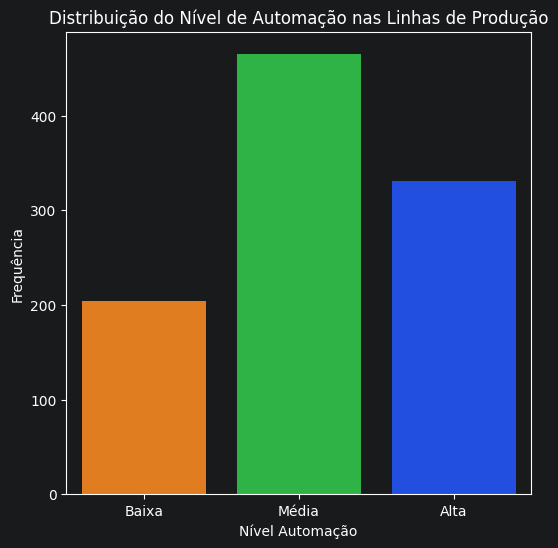

In [74]:
# 4.1 Montando a representação gráfica, respeitando a ordem ordinal
# gráfico de colunas (Nível Automação X frequência absoluta)

# Definindo o tamanho/escala do gráfico
fig, ax = plt.subplots(figsize=(6,6))

# Construindo o gráfico com x sendo Nível Automação e respeitando a
# ordem definida anteriormente Também foi adicionado estilização como
# título, esconder a legenda e o palette para deixar o gráfico mais claro
sns.countplot(x='Nivel_Automacao', data=df, order=ordem,
              hue='Nivel_Automacao', palette='bright',
              legend=False, ax=ax)

ax.set_xlabel("Nível Automação", size=10)
ax.set_ylabel("Frequência", size=10)
ax.set_title("Distribuição do Nível de Automação nas Linhas de Produção", size=12)
plt.show()

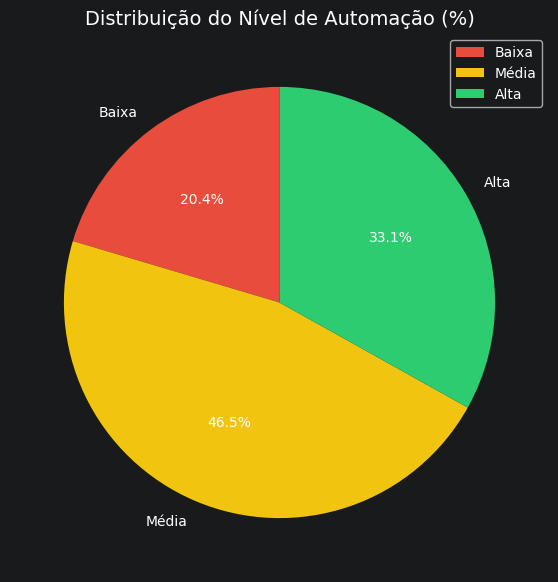

In [75]:
# 4.2 Gráfico de setor (pizza) -> visualização complementar em %
rotulos = tabela['Nível Automação'].tolist()
valores = tabela['Frequência'].tolist()

plt.figure(figsize=(7,7))
plt.pie(valores, labels=rotulos, autopct='%1.1f%%', startangle=90, colors=['#e74c3c', '#f1c40f', '#2ecc71'])
plt.title("Distribuição do Nível de Automação (%)", fontsize=14)
plt.legend()
plt.show()

#### 5. Medidas de Resumo -> Moda

In [76]:
# Calculando e encontrando a moda da variável Nível Automação
moda_automacao = df.Nivel_Automacao.mode()
moda_automacao

0    Média
Name: Nivel_Automacao, dtype: object

A moda da variável Nível de Automação é **"Média"**, ou seja, entre as 1000 linhas de produção analisadas,
a categoria mais frequente é o nível Médio, com 465 ocorrências (46,5% da amostra).

Por se tratar de uma variável qualitativa ordinal (Baixa, Média, Alta), a moda é a única medida
de tendência central aplicável — média e mediana não fazem sentido aqui, pois as categorias não possuem valor
numérico. A unidade de medida corrresponde à própria categoria (nível de automação)